# Deteção de pose utilizando o YOLO

## Aplicação do modelo e interpretação do resultado

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

model = YOLO("yolo26n-pose.pt")

# Nomes dos keypoints (joints) para o modelo de pose
kpt_names = model.model.kpt_names[0]
print(kpt_names)

['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow', 'left_wrist', 'right_wrist', 'left_hip', 'right_hip', 'left_knee', 'right_knee', 'left_ankle', 'right_ankle']


In [2]:
img = Image.open("../../dados/cameraman.tiff").convert("RGB")
result = model.predict(img)[0]

# Resultados como um numpy array
kpt_data = result.keypoints.data
# O tamanho do array é (num_pessoas, num_keypoints, 3), onde 3 corresponde às coordenadas (x, y) 
# e a confiança de que o ponto é válido e está visível
print(kpt_data.shape)  

0: 640x640 1 person, 55.7ms
Speed: 1.7ms preprocess, 55.7ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)
torch.Size([1, 17, 3])


In [3]:
for idx, person_kpts in enumerate(kpt_data):
    print(f"Pessoa {idx}:")
    for kpt_idx, (x, y, conf) in enumerate(person_kpts):
        print(f"  {kpt_names[kpt_idx]}: ({x:.2f}, {y:.2f}), conf={conf:.2f}")

Pessoa 0:
  nose: (129.64, 67.55), conf=0.99
  left_eye: (130.28, 62.46), conf=0.43
  right_eye: (125.56, 61.94), conf=0.99
  left_ear: (123.80, 62.27), conf=0.01
  right_ear: (110.20, 61.09), conf=0.95
  left_shoulder: (115.95, 91.40), conf=0.99
  right_shoulder: (83.66, 75.80), conf=0.99
  left_elbow: (118.84, 131.27), conf=0.97
  right_elbow: (42.13, 103.58), conf=0.99
  left_wrist: (134.14, 113.51), conf=0.97
  right_wrist: (81.38, 121.89), conf=1.00
  left_hip: (79.75, 164.00), conf=0.99
  right_hip: (59.97, 159.05), conf=1.00
  left_knee: (58.73, 229.46), conf=0.93
  right_knee: (72.04, 226.74), conf=0.98
  left_ankle: (44.37, 255.48), conf=0.02
  right_ankle: (70.47, 256.00), conf=0.03


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

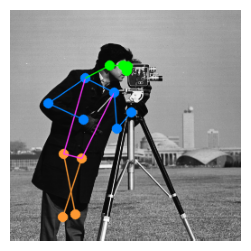

In [6]:
img_res = result.plot(
    boxes=False, 
)

img_res = img_res[:, :, ::-1]  # Converte BGR para RGB

plt.figure()
plt.imshow(img_res)
plt.axis("off")

## Visualização do resultado

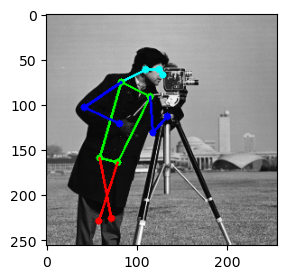

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Define a conectividade entre os pontos para desenhar um esqueleto
POSE_STRUCTURE = {
    "head": {
        "keypoints": [0, 1, 2, 3, 4],
        # Conexões entre os keypoints 
        "edges": [(0, 1), (0, 2), (1, 3), (2, 4), (3, 5), (4, 6)], 
        "color": (0, 255, 255)
    },
    "torso": {
        "keypoints": [5, 6, 11, 12],
        "edges": [(5, 6), (11, 12), (5, 11), (6, 12)],
        "color": (0, 255, 0)
    },
    "arms": {
        "keypoints": [7, 8, 9, 10],
        "edges": [(5, 7), (7, 9), (6, 8), (8, 10)],
        "color": (0, 0, 255)
    },
    "legs": {
        "keypoints": [13, 14, 15, 16],
        "edges": [(11, 13), (13, 15), (12, 14), (14, 16)],
        "color": (255, 0, 0) 
    }
}

def plot_pose(img, kpt_data, conf=0.5, radius=5, thickness=2):
    """
    Plota os keypoints e as conexões (esqueleto) em uma imagem.
    """
    # Create a copy to avoid modifying the original image directly
    img_copy = img.copy()
    
    for person_kpts in kpt_data:
        for part, data in POSE_STRUCTURE.items():
            color = data["color"]
            
            for edge in data["edges"]:
                idx1, idx2 = edge
                
                # Checa se ambos os pontos têm confiança suficiente para serem desenhados
                if person_kpts[idx1, 2] > conf and person_kpts[idx2, 2] > conf:    
                    pt1 = (int(person_kpts[idx1, 0]), int(person_kpts[idx1, 1]))
                    pt2 = (int(person_kpts[idx2, 0]), int(person_kpts[idx2, 1]))
                    
                    # Em alguns casos, os pontos podem ser (0, 0) se não forem detectados 
                    # corretamente, então é bom checar isso antes de desenhar a linha
                    if pt1 != (0, 0) and pt2 != (0, 0):
                        cv2.line(img_copy, pt1, pt2, color, thickness)
                
            # Desenha os keypoints como círculos
            for kp_idx in data["keypoints"]:
                if person_kpts[kp_idx, 2] > conf:                        
                    pt = (int(person_kpts[kp_idx, 0]), int(person_kpts[kp_idx, 1]))
                    if pt != (0, 0):                       
                        # -1 indica que o círculo deve ser preenchido
                        cv2.circle(img_copy, pt, radius, color, -1) 

    return img_copy

annotated_img = plot_pose(
    img=np.array(img), 
    kpt_data=kpt_data, 
    conf=0.5, 
    radius=4,       
    thickness=2     
)

plt.imshow(annotated_img)


0: 384x640 13 persons, 37.9ms
Speed: 0.8ms preprocess, 37.9ms inference, 0.1ms postprocess per image at shape (1, 3, 384, 640)


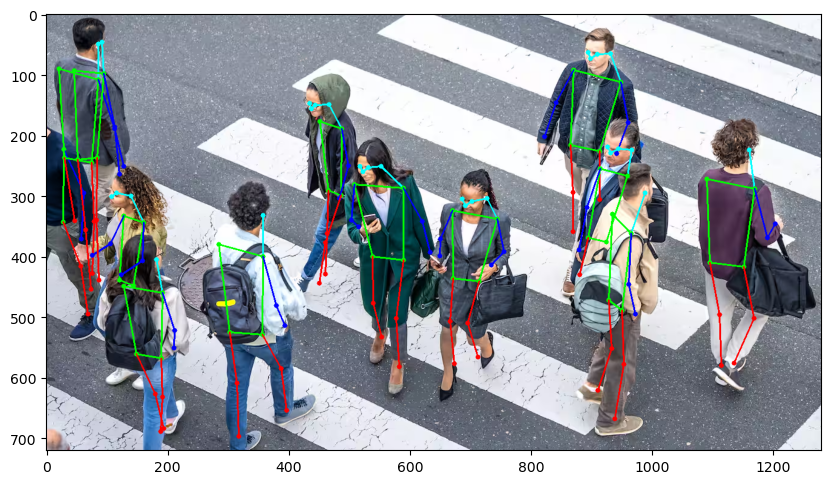

In [5]:
img = Image.open("../../dados/pedestrians.png")
result = model.predict(img)[0]

annotated_img = plot_pose(
    img=np.array(img), 
    kpt_data=result.keypoints.data, 
    conf=0.5, 
    radius=4,       
    thickness=2     
)

plt.figure(figsize=(10, 10))
plt.imshow(annotated_img)